In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## GROUP 13 Lab 05

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196

#  PROBLEM 2 : Analytical approach


The numerical model used earlier represents the chain as a finite number of discrete masses connected by springs. However, the same physical problem can also be studied analytically by considering the **continuum limit**, where the number of masses becomes very large and the chain behaves like a continuous curve.

In this limit, the equilibrium shape can be obtained using the **calculus of variations**. Instead of minimizing a discrete sum of energies, the total potential energy of a continuous chain is minimized. The energy functional can be written as

$$
E = \int \rho g\, y \, ds
$$

where \( \rho \) is the mass per unit length, \( g \) is the gravitational acceleration, \( y \) is the vertical coordinate, and \( ds \) is an element of arc length of the curve.

Minimizing this energy using the Euler–Lagrange equation leads to the well-known **catenary solution**

$$
y = a \cosh\left(\frac{x}{a}\right)
$$

which describes the equilibrium shape of a hanging chain.

To compare the analytical prediction with the numerical model, the catenary curve can be plotted together with the numerical solution obtained from the mass–spring simulation. As the number of masses increases, the numerical solution approaches the smooth catenary curve predicted by the analytical approach.

In [ ]:
#code from previous solution
N = 20
m = 1.0
g = 9.8
k = 50.0
L0 = 1.0
def total_energy(y_middle):


    y = np.concatenate(([0], y_middle, [0]))

    E_gravity = 0
    E_spring = 0


    for j in range(len(y)):
        E_gravity += m * g * y[j]


    for j in range(len(y) - 1):
        dy = y[j+1] - y[j]
        length = np.sqrt(1 + dy**2)
        E_spring += 0.5 * k * (length - L0)**2

    return E_gravity + E_spring

initial_guess = np.zeros(N-2)
result = minimize(total_energy, initial_guess)
y_middle = result.x
y = np.concatenate(([0], y_middle, [0]))
x = np.arange(N)


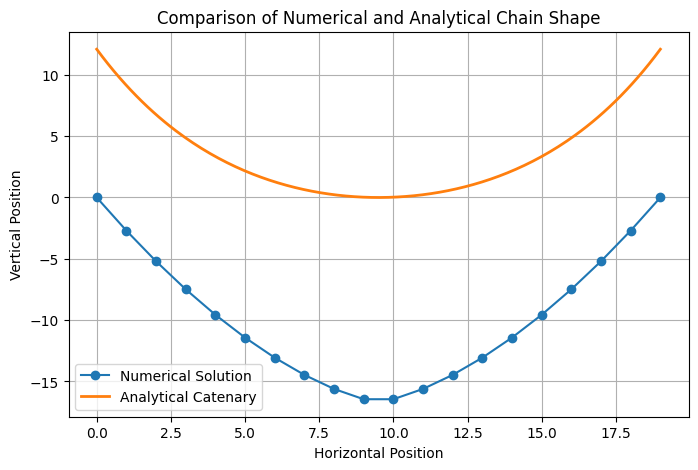

In [6]:
# Analytical catenary curve for comparison

a = 5   # parameter controlling curvature

x_cont = np.linspace(0, N-1, 200)


x_shift = x_cont - (N-1)/2

y_catenary = a * np.cosh(x_shift/a) - a

plt.figure(figsize=(8,5))

# numerical solution from mass-spring model
plt.plot(x, y, 'o-', label="Numerical Solution")

# analytical catenary curve
plt.plot(x_cont, y_catenary, label="Analytical Catenary", linewidth=2)

plt.xlabel("Horizontal Position")
plt.ylabel("Vertical Position")
plt.title("Comparison of Numerical and Analytical Chain Shape")
plt.legend()
plt.grid(True)
plt.show()